Jose E Rodriguez Rios

In [283]:
# Install required libraries (if not already installed)
!pip install tensorflow pandas numpy scikit-learn matplotlib

# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler





In [284]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [285]:
pd.set_option('display.max_columns', None)

In [286]:
data_file_location = "./"
data_file_name = "conn.log.labeled"

In [287]:


# Column names are included in the file in a commented line, so we need to read the corresponding line separately and remove the first description word.
data_columns = pd.read_csv(data_file_location + data_file_name, sep='\t', skiprows=6, nrows=1, header=None).iloc[0][1:]

# Read the actual dataset
df = pd.read_csv(data_file_location + data_file_name, sep='\t', comment="#", header=None)

# Set column names
df.columns = data_columns



In [288]:
df.shape

(23145, 23)

In [289]:
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,local_orig,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,det_label
0,1.545404e+09,CrDn63WjJEmrWGjqf,192.168.1.195,41040,185.244.25.235,80,tcp,-,3.139211,0,0,S0,-,-,0,S,3,180,0,0,-,Benign,-
1,1.545404e+09,CY9lJW3gh1Eje4usP6,192.168.1.195,41040,185.244.25.235,80,tcp,-,-,-,-,S0,-,-,0,S,1,60,0,0,-,Benign,-
2,1.545404e+09,CcFXLynukEDnUlvgl,192.168.1.195,41040,185.244.25.235,80,tcp,-,-,-,-,S0,-,-,0,S,1,60,0,0,-,Benign,-
3,1.545404e+09,CDrkrSobGYxHhYfth,192.168.1.195,41040,185.244.25.235,80,tcp,http,1.477656,149,128252,SF,-,-,2896,ShADadttcfF,94,5525,96,139044,-,Benign,-
4,1.545404e+09,CTWZQf2oJSvq6zmPAc,192.168.1.195,41042,185.244.25.235,80,tcp,-,3.147116,0,0,S0,-,-,0,S,3,180,0,0,-,Benign,-


In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23145 entries, 0 to 23144
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ts              23145 non-null  float64
 1   uid             23145 non-null  object 
 2   id.orig_h       23145 non-null  object 
 3   id.orig_p       23145 non-null  int64  
 4   id.resp_h       23145 non-null  object 
 5   id.resp_p       23145 non-null  int64  
 6   proto           23145 non-null  object 
 7   service         23145 non-null  object 
 8   duration        23145 non-null  object 
 9   orig_bytes      23145 non-null  object 
 10  resp_bytes      23145 non-null  object 
 11  conn_state      23145 non-null  object 
 12  local_orig      23145 non-null  object 
 13  local_resp      23145 non-null  object 
 14  missed_bytes    23145 non-null  int64  
 15  history         23145 non-null  object 
 16  orig_pkts       23145 non-null  int64  
 17  orig_ip_bytes   23145 non-null 

In [291]:
# Inspect unique values in 'det_label'
print(df['det_label'].unique())


['-' 'C&C' 'PartOfAHorizontalPortScan' 'DDoS']


In [292]:
# Replace placeholder values with NaN or 'Unknown'
df['det_label'].replace('-', np.nan, inplace=True)

<ipython-input-292-d643f46a0d89>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['det_label'].replace('-', np.nan, inplace=True)


In [293]:
print(df['det_label'].unique())


[nan 'C&C' 'PartOfAHorizontalPortScan' 'DDoS']


In [294]:
# Replace unset placeholders with NaN
df.replace({'-': np.nan, '(empty)': np.nan}, inplace=True)

# Convert misinterpreted numeric columns to proper data types
numeric_columns = ['duration', 'orig_bytes', 'resp_bytes']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


<ipython-input-294-99264ad5be9b>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'-': np.nan, '(empty)': np.nan}, inplace=True)


In [295]:
split_columns = df['det_label'].str.split('|', expand=True)

In [296]:
# Count unique values for each column
unique_counts = df.nunique()

# Display columns with all unique or single unique values
print("Columns with all unique values:")
print(unique_counts[unique_counts == len(df)])  # Likely IDs or timestamps

print("\nColumns with a single unique value:")
print(unique_counts[unique_counts == 1])  # Not useful for modeling



Columns with all unique values:
0
ts     23145
uid    23145
dtype: int64

Columns with a single unique value:
Series([], dtype: int64)


In [297]:
df.nunique().sort_values(ascending=False)

,0
0,
ts,23145
uid,23145
duration,4653
id.orig_p,4383
orig_ip_bytes,108
resp_ip_bytes,62
orig_pkts,53
id.resp_h,49
resp_bytes,43


In [298]:
#No need for IPs or UID because of biased
#tunnel parents local resp and local_origen doesnt have anything
irrelevant_cols = ['uid', 'ts', 'id.orig_h', 'id.resp_h', 'local_resp', 'local_orig', 'tunnel_parents']
df.drop(columns=irrelevant_cols, inplace=True)

In [299]:
df.head()

,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,det_label
0,41040,80,tcp,NaN,3.139211,0.0,0.0,S0,0,S,3,180,0,0,Benign,NaN
1,41040,80,tcp,NaN,NaN,NaN,NaN,S0,0,S,1,60,0,0,Benign,NaN
2,41040,80,tcp,NaN,NaN,NaN,NaN,S0,0,S,1,60,0,0,Benign,NaN
3,41040,80,tcp,http,1.477656,149.0,128252.0,SF,2896,ShADadttcfF,94,5525,96,139044,Benign,NaN
4,41042,80,tcp,NaN,3.147116,0.0,0.0,S0,0,S,3,180,0,0,Benign,NaN


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23145 entries, 0 to 23144
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id.orig_p      23145 non-null  int64  
 1   id.resp_p      23145 non-null  int64  
 2   proto          23145 non-null  object 
 3   service        1847 non-null   object 
 4   duration       5321 non-null   float64
 5   orig_bytes     5321 non-null   float64
 6   resp_bytes     5321 non-null   float64
 7   conn_state     23145 non-null  object 
 8   missed_bytes   23145 non-null  int64  
 9   history        23145 non-null  object 
 10  orig_pkts      23145 non-null  int64  
 11  orig_ip_bytes  23145 non-null  int64  
 12  resp_pkts      23145 non-null  int64  
 13  resp_ip_bytes  23145 non-null  int64  
 14  label          23145 non-null  object 
 15  det_label      21222 non-null  object 
dtypes: float64(3), int64(7), object(6)
memory usage: 2.8+ MB


In [301]:
df["label"].isna().sum()

0

In [302]:
df["label"].value_counts()

,count
label,
Malicious,21222
Benign,1923


0
service          21298
duration         17824
orig_bytes       17824
resp_bytes       17824
det_label         1923
id.orig_p            0
id.resp_p            0
proto                0
conn_state           0
missed_bytes         0
history              0
orig_pkts            0
orig_ip_bytes        0
resp_pkts            0
resp_ip_bytes        0
label                0
dtype: int64


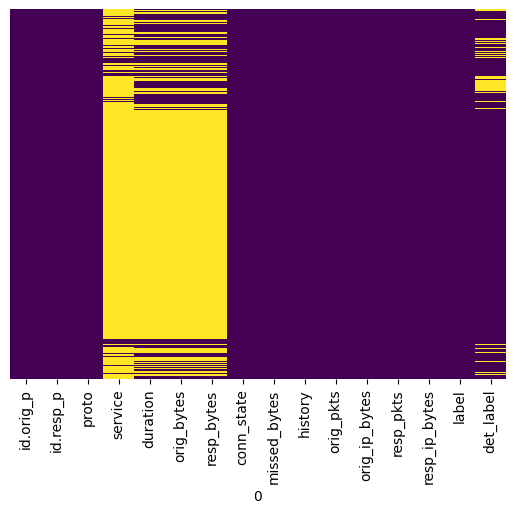

In [303]:
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import  OneHotEncoder
print(df.isnull().sum().sort_values(ascending=False))
sns.heatmap(data=df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.show()


In [304]:
# Encode the target column
target_encoder = LabelEncoder()
df['label'] = target_encoder.fit_transform(df['label'])

# Map encoded values for reference
label_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")


Label Mapping: {'Benign': 0, 'Malicious': 1}


In [305]:
# Apply IQR method to remove outliers
def cap_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                          np.where(df[column] < lower_bound, lower_bound, df[column]))

# Apply to "duration" column
cap_outliers(df, 'duration')


In [306]:
# Impute numerical features using KNNImputer
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features.remove('label')  # Exclude target column
imputer = KNNImputer(n_neighbors=3)
df[numerical_features] = imputer.fit_transform(df[numerical_features])


In [307]:
# Impute missing values for "service" using a simple classifier
categorical_features = ['service']
for feature in categorical_features:
    missing_data = df[feature].isna()
    if missing_data.any():
        known_data = df.loc[~missing_data, :]
        unknown_data = df.loc[missing_data, :]

        # Train a simple model (e.g., DecisionTreeClassifier) to fill missing values
        from sklearn.tree import DecisionTreeClassifier

        model = DecisionTreeClassifier()
        model.fit(known_data[numerical_features], known_data[feature])
        df.loc[missing_data, feature] = model.predict(unknown_data[numerical_features])

In [308]:
scaler = MinMaxScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])


In [309]:
# One-hot encode categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df[categorical_features])

# Create a new DataFrame for the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Merge with the original DataFrame and drop the original categorical columns
df = pd.concat([df, encoded_df], axis=1).drop(categorical_features, axis=1)


In [310]:
df.columns

Index(['id.orig_p', 'id.resp_p', 'duration', 'orig_bytes', 'resp_bytes',
       'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts',
       'resp_ip_bytes', 'label', 'proto_tcp', 'proto_udp', 'service_dhcp',
       'service_dns', 'service_http', 'service_irc', 'conn_state_OTH',
       'conn_state_RSTR', 'conn_state_S0', 'conn_state_S1', 'conn_state_S3',
       'conn_state_SF', 'history_C', 'history_CCC', 'history_CCCC',
       'history_D', 'history_Dd', 'history_DdAtaFf', 'history_S',
       'history_ShAD', 'history_ShADacdtfF', 'history_ShADad',
       'history_ShADadf', 'history_ShADadtcfF', 'history_ShADadtctfF',
       'history_ShADadtctfFR', 'history_ShADadttcfF', 'history_ShADadttfF',
       'history_ShAdD', 'history_ShAdDa', 'history_ShAdDaf',
       'history_ShAdDaft', 'history_ShAdDatf', 'history_ShAdDatfr',
       'history_ShAdDfr', 'history_ShAdfDr', 'history_ShAfdtDr',
       'history_ShDadAf', 'det_label_C&C', 'det_label_DDoS',
       'det_label_PartOfAHorizontalPort

In [311]:
print(df.describe())


          id.orig_p     id.resp_p      duration    orig_bytes    resp_bytes  \
count  23145.000000  23145.000000  23145.000000  2.314500e+04  23145.000000   
mean       0.864132      0.036421      0.605765  4.546020e-05      0.000504   
std        0.263126      0.084062      0.205480  6.578095e-03      0.015723   
min        0.000000      0.000000      0.000000  0.000000e+00      0.000000   
25%        0.821428      0.001238      0.618917  6.353692e-07      0.000000   
50%        1.000000      0.001238      0.666667  6.883167e-07      0.000000   
75%        1.000000      0.104488      0.666667  6.883167e-07      0.000000   
max        1.000000      1.000000      1.000000  1.000000e+00      1.000000   

       missed_bytes     orig_pkts  orig_ip_bytes     resp_pkts  resp_ip_bytes  \
count  23145.000000  23145.000000   2.314500e+04  23145.000000   23145.000000   
mean       0.000367      0.000346   4.817466e-05      0.000571       0.000658   
std        0.017695      0.009681   6.578439e

In [312]:
df['label']

,label
0,0
1,0
2,0
3,0
4,0
...,...
23140,1
23141,1
23142,0
23143,0


In [313]:
# Define features and target
X = df.drop(columns=['label'])
y = df['label']

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [314]:
# Reshape the data for transformer input
X_train_reshaped = X_train_scaled[:, None, :]  # Shape: (batch_size, sequence_length=1, num_features)
X_val_reshaped = X_val_scaled[:, None, :]
X_test_reshaped = X_test_scaled[:, None, :]

print(f"X_train reshaped: {X_train_reshaped.shape}")
print(f"X_val reshaped: {X_val_reshaped.shape}")
print(f"X_test reshaped: {X_test_reshaped.shape}")

X_train reshaped: (16201, 1, 52)
X_val reshaped: (3472, 1, 52)
X_test reshaped: (3472, 1, 52)


In [315]:
def build_transformer_model(input_dim):
    inputs = layers.Input(shape=(1, input_dim))  # Input shape: (sequence_length=1, num_features)

    # Transformer Encoder
    attention_output = layers.MultiHeadAttention(num_heads=4, key_dim=input_dim)(inputs, inputs)
    attention_output = layers.LayerNormalization()(attention_output + inputs)  # Residual connection

    # Feed-forward Network
    ff_output = layers.Dense(64, activation='relu')(attention_output)
    ff_output = layers.Dense(input_dim)(ff_output)  # Project back to input_dim
    ff_output = layers.LayerNormalization()(ff_output + attention_output)  # Residual connection

    # Flatten and Output Layer
    flat_output = layers.Flatten()(ff_output)
    outputs = layers.Dense(1, activation='sigmoid')(flat_output)  # Binary classification

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


In [316]:
# Build the model
model = build_transformer_model(X_train_reshaped.shape[2])
model.compile(optimizer='adam', loss='binaroy_crssentropy', metrics=['accuracy'])

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11            │ (None, 1, 52)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_11   │ (None, 1, 52)          │         43,940 │ input_layer_11[0][0],  │
│ (MultiHeadAttention)      │                        │                │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_22 (Add)              │ (None, 1, 52)          │              0 │ multi_head_attention_… │
│                           │                        │                │ input_layer_11[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_22    │ (None, 1, 52)          │            104 │ add_22[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_37 (Dense)          │ (None, 1, 64)          │          3,392 │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_38 (Dense)          │ (None, 1, 52)          │          3,380 │ dense_37[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_23 (Add)              │ (None, 1, 52)          │              0 │ dense_38[0][0],        │
│                           │                        │                │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_23    │ (None, 1, 52)          │            104 │ add_23[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 52)             │              0 │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_39 (Dense)          │ (None, 1)              │             53 │ flatten_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 50,973 (199.11 KB)

 Trainable params: 50,973 (199.11 KB)

 Non-trainable params: 0 (0.00 B)

In [317]:
history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


507/507 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9944 - loss: 0.0215 - val_accuracy: 1.0000 - val_loss: 3.1867e-04
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 1.5844e-04 - val_accuracy: 1.0000 - val_loss: 5.7023e-05
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 5.1118e-05 - val_accuracy: 1.0000 - val_loss: 3.1252e-05
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 2.8761e-05 - val_accuracy: 1.0000 - val_loss: 1.9792e-05
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.8339e-05 - val_accuracy: 1.0000 - val_loss: 1.3437e-05
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.1654e-05 - val_accuracy: 1.0000 - val_loss: 9.4664e-06
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 8.8482e-06 - val_accuracy: 1.0000 - val_loss: 6.8514e-06
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy:

In [318]:
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 5.2689e-05
Test Accuracy: 99.97%


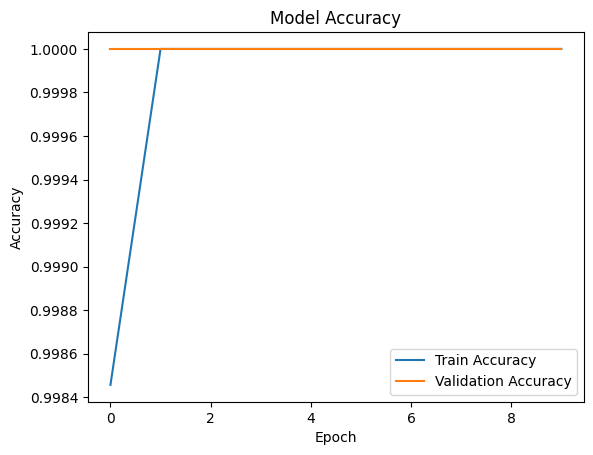

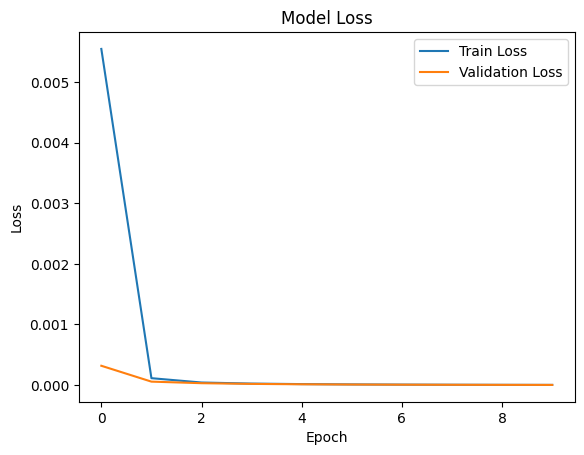

In [319]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [320]:
# Check correlation between features and target
correlation_matrix = pd.concat([X, y], axis=1).corr()
print(correlation_matrix['label'].sort_values(ascending=False))


label                                  1.000000
proto_tcp                              0.967596
id.orig_p                              0.866659
duration                               0.688168
det_label_DDoS                         0.386063
conn_state_OTH                         0.381353
history_C                              0.381075
service_http                           0.356302
service_irc                            0.194726
det_label_C&C                          0.192261
history_S                              0.130165
id.resp_p                              0.124155
conn_state_S3                          0.081591
history_ShAdDaf                        0.078592
det_label_PartOfAHorizontalPortScan    0.021913
history_ShAdDaft                       0.020028
conn_state_RSTR                        0.014421
history_ShAdfDr                        0.013723
history_CCCC                           0.004847
conn_state_S1                          0.003958
history_ShAfdtDr                       0

In [321]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred = (model.predict(X_test_reshaped) > 0.5).astype("int32")

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


104/109 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       296
           1       1.00      1.00      1.00      3176

    accuracy                           1.00      3472
   macro avg       1.00      1.00      1.00      3472
weighted avg       1.00      1.00      1.00      3472

[[ 295    1]
 [   0 3176]]
